## **Tollywood Trends and Insights**

#### **Import Libraries**

In [89]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [90]:
plt.style.use("dark_background")

In [91]:

colors =  [
    "#3a0ca3",  # deep violet
    "#560bad",  
    "#7209b7",
    "#b5179e",  # neon magenta
    "#f72585",  # neon pink
    "#ff4d6d",  
    "#ff758f",
    "#ffccd5"
]



#### **Original Dataset**

In [92]:
df=pd.read_csv(r"telugu movie data with year")
df.head(10)

,S.no,Movie Title,Genre,Budget (Cr),Director Success Rate,Lead Actor Success Rate,IMDb,Trailer Views (M),Box Office Revenue,Released Year
0,1,Aadavallu Meeku Johaarlu,Romance,20.0,71.42,51.72,5.8,9.500,7.72,2022.0
1,1,Ala Modalaindi,Romance,4.0,66.60,65.00,7.6,0.970,15.00,2011.0
2,2,Ammammagarillu,Romance,1.5,0.00,23.00,5.3,0.221,21.50,2018.0
3,3,Anni Manchi Sakunamule,Romance,12.0,66.60,22.22,6.1,3.700,4.45,2023.0
4,4,Appudo Ippudo Eppudo,Romance,15.0,75.00,55.00,4.7,3.500,0.70,2024.0
5,5,Arya 2,Romance,21.0,80.00,52.63,7.5,58.000,25.00,2009.0
6,6,Ashoka Vanamlo Arjuna Kalyanam,Romance,10.0,66.66,30.00,7.4,3.200,9.00,2022.0
7,7,Baby,Romance,10.0,80.00,33.30,7.1,22.000,80.00,2015.0
8,8,Chal Mohan Ranga,Romance,25.0,33.33,29.00,5.9,10.000,8.50,2018.0
9,9,Chitralahari,Romance,25.0,71.42,56.25,7.1,5.800,26.05,2019.0


In [73]:
df.shape

(405, 10)

In [93]:
df.drop_duplicates()

,S.no,Movie Title,Genre,Budget (Cr),Director Success Rate,Lead Actor Success Rate,IMDb,Trailer Views (M),Box Office Revenue,Released Year
0,1,Aadavallu Meeku Johaarlu,Romance,20.0,71.42,51.72,5.8,9.500,7.72,2022.0
1,1,Ala Modalaindi,Romance,4.0,66.60,65.00,7.6,0.970,15.00,2011.0
2,2,Ammammagarillu,Romance,1.5,0.00,23.00,5.3,0.221,21.50,2018.0
3,3,Anni Manchi Sakunamule,Romance,12.0,66.60,22.22,6.1,3.700,4.45,2023.0
4,4,Appudo Ippudo Eppudo,Romance,15.0,75.00,55.00,4.7,3.500,0.70,2024.0
...,...,...,...,...,...,...,...,...,...,...
400,488,Samudram,Drama,6.0,70.00,60.00,8.3,0.340,10.00,1999.0
401,489,Sarileru Neekevvaru,Drama,75.0,85.00,90.00,7.9,25.300,260.00,2020.0
402,490,Seethamma Vakitlo Sirimalle Chettu,Drama,50.0,75.00,80.00,8.4,3.800,51.00,2013.0
403,491,Sye,Drama,10.0,80.00,75.00,7.9,0.006,22.00,2004.0


In [75]:
df.isna().sum()

S.no                        0
Movie Title                 0
Genre                       0
Budget (Cr)                 0
Director Success Rate       0
Lead Actor Success Rate     0
IMDb                        0
Trailer Views (M)           0
Box Office Revenue          0
Released Year              11
dtype: int64

In [76]:
df=df.dropna()

In [77]:
df = df[df["IMDb"] != 43]

#### 1.  Average movie budget

In [78]:
budget_arr = df["Budget (Cr)"].dropna().to_numpy()
print("Average  movie budget (Cr):", np.mean(budget_arr))

Average  movie budget (Cr): 40.30769083969466


#### 2. Median IMDb rating

In [79]:

imdb_arr = df["IMDb"].dropna().to_numpy()
print(" Median IMDb rating:", np.median(imdb_arr))


 Median IMDb rating: 6.6


#### 3. Standard deviation of Box Office Revenue

In [80]:

rev_arr = df["Box Office Revenue"].dropna().to_numpy()
print(" Std dev of Box Office Revenue (Cr):", np.std(rev_arr))


 Std dev of Box Office Revenue (Cr): 175.2907880468304


#### 4.  Display all unique genres in the dataset.


In [81]:

df["Genre"].unique()


array(['Romance', 'Action', 'Comedy', 'Thriller', 'Drama'], dtype=object)

#### 5. Which movie has the highest IMDb rating?

In [82]:

df.loc[df["IMDb"].idxmax(), ["Movie Title", "IMDb"]]


Movie Title    C/o Kancharapalem
IMDb                         9.5
Name: 352, dtype: object

#### 6. Which movie earned the highest box office revenue?

In [83]:

df.loc[df["Box Office Revenue"].idxmax(), ["Movie Title", "Box Office Revenue"]]


Movie Title           Baahubali 2: The Conclusion
Box Office Revenue                         1810.0
Name: 377, dtype: object

#### 7. Calculate the average budget of all movies.

In [84]:

df["Budget (Cr)"].mean()


np.float64(40.30769083969466)

#### 8. List all movies with IMDb rating greater than 7.0.

In [85]:

df[df["IMDb"] > 7.0][["Movie Title", "IMDb"]]


,Movie Title,IMDb
1,Ala Modalaindi,7.6
5,Arya 2,7.5
6,Ashoka Vanamlo Arjuna Kalyanam,7.4
7,Baby,7.1
9,Chitralahari,7.1
...,...,...
399,Rangasthalam,8.4
400,Samudram,8.3
401,Sarileru Neekevvaru,7.9
402,Seethamma Vakitlo Sirimalle Chettu,8.4


#### 9. Add a new column 'Profit' = Revenue - Budget.

In [86]:

df = df.copy()   
df.loc[:, "Profit"] = df["Box Office Revenue"] - df["Budget (Cr)"]
df.head()


,S.no,Movie Title,Genre,Budget (Cr),Director Success Rate,Lead Actor Success Rate,IMDb,Trailer Views (M),Box Office Revenue,Released Year,Profit
0,1,Aadavallu Meeku Johaarlu,Romance,20.0,71.42,51.72,5.8,9.500,7.72,2022.0,-12.28
1,1,Ala Modalaindi,Romance,4.0,66.60,65.00,7.6,0.970,15.00,2011.0,11.00
2,2,Ammammagarillu,Romance,1.5,0.00,23.00,5.3,0.221,21.50,2018.0,20.00
3,3,Anni Manchi Sakunamule,Romance,12.0,66.60,22.22,6.1,3.700,4.45,2023.0,-7.55
4,4,Appudo Ippudo Eppudo,Romance,15.0,75.00,55.00,4.7,3.500,0.70,2024.0,-14.30


#### 10. Sort movies by Profit in descending order.

In [87]:

df.sort_values("Profit", ascending=False)[["Movie Title", "Profit"]].head(10)


,Movie Title,Profit
377,Baahubali 2: The Conclusion,1560.00
44,Pushpa: The Rule - Part 2,1290.00
248,Kalki-2989AD,1000.00
38,RRR,650.00
39,Baahubali: The Beginning,470.00
43,Kalki 2898 AD,454.67
42,Salaar,430.00
49,Hanu Man,254.18
91,Warrior,243.20
122,Sankrathiki Vasthunam,210.00


#### Top 10 Profit Movies

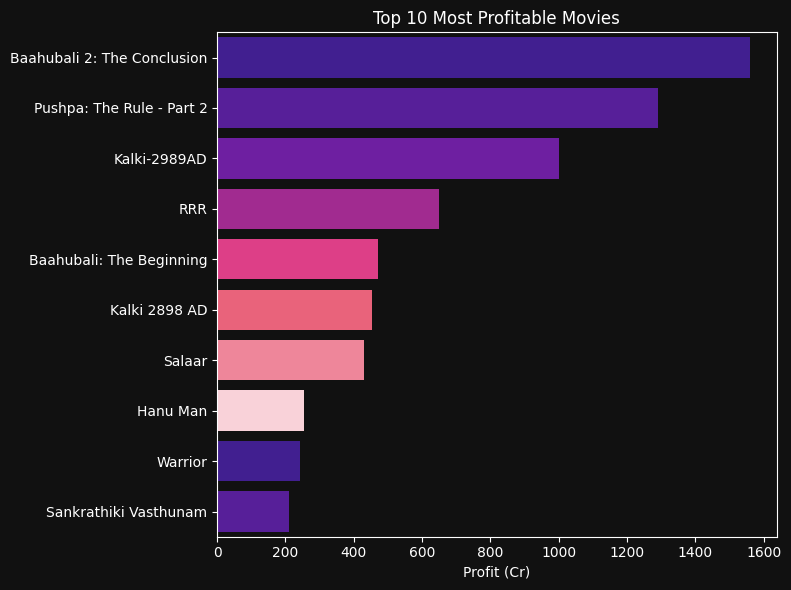

In [88]:
top_profit = df.nlargest(10, "Profit")

bg = "#111111"   
plt.figure(figsize=(8,6), facecolor=bg)
ax = plt.gca()
ax.set_facecolor(bg)

sns.barplot(
    data=top_profit,
    x="Profit",
    y="Movie Title",
    hue="Movie Title",     
    palette=colors[:len(top_profit)],        
    dodge=False,
    legend=False
)

plt.xlabel("Profit (Cr)", color="white")
plt.ylabel("", color="white")
plt.title("Top 10 Most Profitable Movies", color="white")

plt.xticks(color="white")
plt.yticks(color="white")

plt.tight_layout()
plt.show()


#### 11. List movies where Director Success Rate > Lead Actor Success Rate.

In [60]:

df[df["Director Success Rate"] > df["Lead Actor Success Rate"]][["Movie Title"]]


,Movie Title
0,Aadavallu Meeku Johaarlu
1,Ala Modalaindi
3,Anni Manchi Sakunamule
4,Appudo Ippudo Eppudo
5,Arya 2
...,...
397,Raja Rani
399,Rangasthalam
400,Samudram
403,Sye


#### 12. Group movies by Genre and find average revenue.

In [61]:

df.groupby("Genre")["Box Office Revenue"].mean()


Genre
Action      138.896786
Comedy       39.658387
Drama        74.956415
Romance      32.024211
Thriller     41.496238
Name: Box Office Revenue, dtype: float64

#### 13. Genre by total revenue 

In [62]:

genre_revenue = df.groupby("Genre")["Box Office Revenue"].sum().sort_values(ascending=False)
print("Genre by total revenue (top 5):")
print(genre_revenue.head(5))


Genre by total revenue (top 5):
Genre
Action      11667.330
Comedy       4917.640
Thriller     4357.105
Drama        3972.690
Romance      1216.920
Name: Box Office Revenue, dtype: float64


#### Pie Chart Top 10 Genres by Revenue

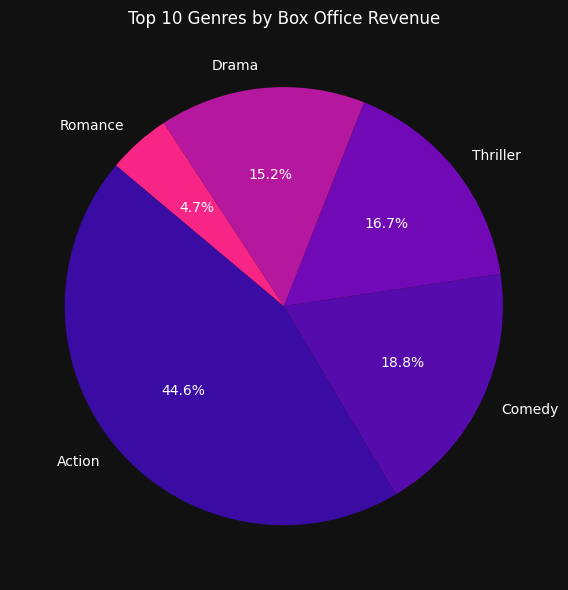

In [63]:
import matplotlib.pyplot as plt

top_genres = genre_revenue.head(10)

bg = "#111111"   
plt.figure(figsize=(6,6), facecolor=bg)
ax = plt.gca()
ax.set_facecolor(bg)

plt.pie(
    top_genres.values,
    labels=top_genres.index,
    autopct="%1.1f%%",
    colors=colors[:len(top_genres)],
    startangle=140,
    textprops={'color':'white'}
)

plt.title("Top 10 Genres by Box Office Revenue", color="white")
plt.tight_layout()
plt.show()


#### 14. Get top 5 movies with highest trailer views.

In [64]:

df.nlargest(5, "Trailer Views (M)")[["Movie Title", "Trailer Views (M)"]]


,Movie Title,Trailer Views (M)
44,Pushpa: The Rule - Part 2,113.0
377,Baahubali 2: The Conclusion,105.0
359,Ala Vaikunthapurramuloo,90.0
38,RRR,85.0
371,Rocky aur Rani ki Prem Kahani,80.0


#### 15. Average budget for each genre

In [65]:

avg_budget_genre = df.groupby("Genre")["Budget (Cr)"].mean().sort_values(ascending=False)
print("Average budget per genre (top 10):")
print(avg_budget_genre.head(10))


Average budget per genre (top 10):
Genre
Action      92.434762
Thriller    36.697071
Drama       28.193774
Romance     19.339474
Comedy      16.840242
Name: Budget (Cr), dtype: float64


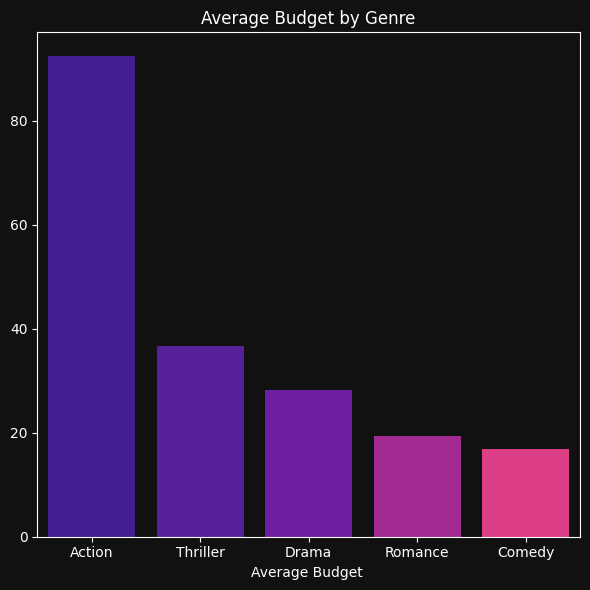

In [66]:

bg = "#111111"   

plt.figure(figsize=(6,6), facecolor=bg)
ax = plt.gca()
ax.set_facecolor(bg)

sns.barplot(
    x=avg_budget_genre.index,          
    y=avg_budget_genre.values,
    hue=avg_budget_genre.index,        
    palette=colors[:len(avg_budget_genre)],
    dodge=False
)


plt.xlabel("Average Budget ", color="white")
plt.ylabel("", color="white")
plt.title("Average Budget by Genre", color="white")
plt.tight_layout()
plt.show()



#### 16. Distribution of movie budgets 

In [67]:

print(" Budget summary statistics:")
print(df["Budget (Cr)"].describe())


 Budget summary statistics:
count    404.000000
mean      39.443249
std       80.720056
min        0.002500
25%        5.750000
50%       15.000000
75%       40.000000
max      700.000000
Name: Budget (Cr), dtype: float64


#### 17. Count of Movies with budget < 10 Cr

In [68]:

count_budget_lt_10 = df[df["Budget (Cr)"] < 10].shape[0]
print("Movies with budget < 10 Cr:", count_budget_lt_10)


Movies with budget < 10 Cr: 137


#### 18.  Find all movies that made a loss (Profit < 0).

In [29]:

df[df["Profit"] < 0][["Movie Title", "Profit"]]


,Movie Title,Profit
0,Aadavallu Meeku Johaarlu,-12.28
3,Anni Manchi Sakunamule,-7.55
4,Appudo Ippudo Eppudo,-14.30
6,Ashoka Vanamlo Arjuna Kalyanam,-1.00
8,Chal Mohan Ranga,-16.50
...,...,...
373,The White Tiger,-25.00
390,NTR Kathanayakudu,-30.00
392,Okka Kshanam,-5.00
398,Rajanna,-12.00


#### 19. Count how many movies were released each year

In [30]:

df["Released Year"].value_counts()


Released Year
2024.0    51
2023.0    49
2022.0    38
2018.0    33
2021.0    25
2016.0    21
2019.0    19
2020.0    16
2017.0    16
2015.0    13
2014.0    12
2025.0    10
2011.0     9
2012.0     9
2008.0     7
2004.0     7
2010.0     6
2006.0     5
1996.0     5
2013.0     5
2001.0     4
2009.0     3
2003.0     3
2007.0     3
2002.0     3
1987.0     2
1993.0     2
1991.0     2
2005.0     2
2000.0     2
1997.0     1
1948.0     1
1940.0     1
1974.0     1
1972.0     1
1990.0     1
1971.0     1
1988.0     1
1985.0     1
1986.0     1
1999.0     1
Name: count, dtype: int64

#### 20. Find the movie with the latest release year


In [31]:
df.loc[df["Released Year"].idxmax()]


S.no                                  88
Movie Title                Daaku Maharaj
Genre                             Action
Budget (Cr)                        100.0
Director Success Rate               80.0
Lead Actor Success Rate             60.0
IMDb                                 6.0
Trailer Views (M)                   18.0
Box Office Revenue                 133.0
Released Year                     2025.0
Profit                              33.0
Name: 47, dtype: object

#### 21.Get movies released between 2015 and 2020 (inclusive)

In [32]:
df[(df["Released Year"] >= 2015) & (df["Released Year"] <= 2020)]


,S.no,Movie Title,Genre,Budget (Cr),Director Success Rate,Lead Actor Success Rate,IMDb,Trailer Views (M),Box Office Revenue,Released Year,Profit
2,2,Ammammagarillu,Romance,1.5,0.00,23.00,5.3,0.221,21.50,2018.0,20.00
7,7,Baby,Romance,10.0,80.00,33.30,7.1,22.000,80.00,2015.0,70.00
8,8,Chal Mohan Ranga,Romance,25.0,33.33,29.00,5.9,10.000,8.50,2018.0,-16.50
9,9,Chitralahari,Romance,25.0,71.42,56.25,7.1,5.800,26.05,2019.0,1.05
10,10,Color Photo,Romance,1.0,100.00,60.00,8.1,5.900,2.62,2020.0,1.62
...,...,...,...,...,...,...,...,...,...,...,...
390,478,NTR Kathanayakudu,Drama,50.0,75.00,80.00,8.4,3.200,20.00,2019.0,-30.00
392,480,Okka Kshanam,Drama,10.0,60.00,65.00,7.8,1.900,5.00,2017.0,-5.00
395,483,Prema Katha Chitram 2,Drama,3.0,50.00,50.00,8.1,1.300,5.00,2018.0,2.00
399,487,Rangasthalam,Drama,60.0,90.00,85.00,8.4,12.700,216.00,2018.0,156.00


#### 22.Find movies released in the most common year (mode)

In [33]:

mode_year = df["Released Year"].mode()[0]
df[df["Released Year"] == mode_year]


,S.no,Movie Title,Genre,Budget (Cr),Director Success Rate,Lead Actor Success Rate,IMDb,Trailer Views (M),Box Office Revenue,Released Year,Profit
4,4,Appudo Ippudo Eppudo,Romance,15.0,75.00,55.00,4.7,3.500,0.70,2024.0,-14.30
27,27,Miss You,Romance,12.0,33.33,44.00,6.2,1.000,3.41,2024.0,-8.59
43,84,Kalki 2898 AD,Action,600.0,100.00,45.45,7.0,31.000,1054.67,2024.0,454.67
44,85,Pushpa: The Rule - Part 2,Action,450.0,77.78,52.63,6.1,113.000,1740.00,2024.0,1290.00
48,89,Devara part 1,Action,300.0,83.33,51.72,6.0,49.000,403.83,2024.0,103.83
49,90,Hanu Man,Action,40.0,75.00,60.00,7.7,25.000,294.18,2024.0,254.18
50,91,Saripodhaa Sanivaaram,Action,90.0,100.00,65.00,7.0,22.000,100.03,2024.0,10.03
51,92,Razakar: The Silent Genocide of Hyderabad,Action,10.0,100.00,12.50,7.4,1.600,0.93,2024.0,-9.07
68,109,Bhaje Vaayu Vegam,Action,15.0,100.00,30.00,6.1,6.100,7.20,2024.0,-7.80
82,123,Marco,Action,30.0,100.00,60.00,6.8,12.300,100.00,2024.0,70.00


#### bar plot of movies per year

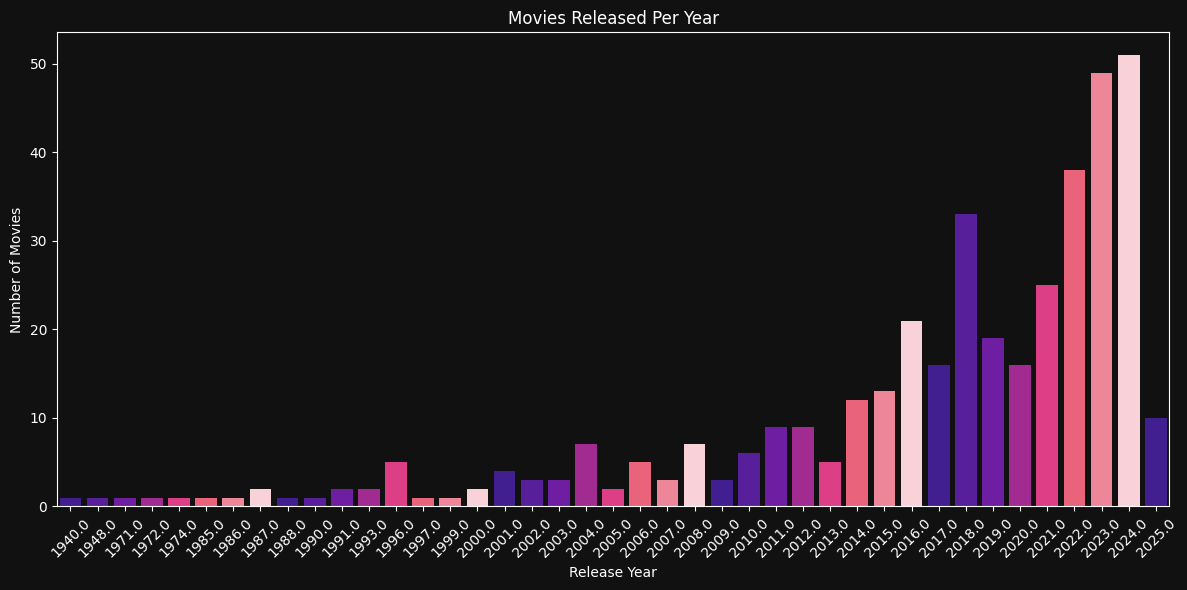

In [34]:
year_counts = df["Released Year"].value_counts().sort_index()

bg = "#111111"
plt.figure(figsize=(12,6), facecolor=bg)
ax = plt.gca()
ax.set_facecolor(bg)
sns.barplot(x=year_counts.index,
            y=year_counts.values,
            palette=colors * (len(year_counts) // len(colors) + 1)
           )

plt.xticks(rotation=45)
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.title("Movies Released Per Year")
plt.tight_layout()
plt.show()

#### Distribution of IMDb Ratings(HISTOGRAM)

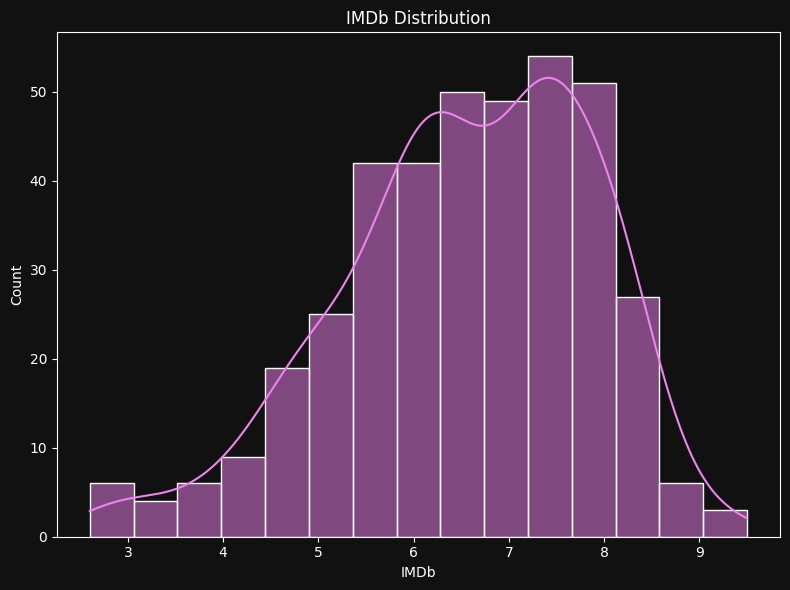

In [35]:
bg = "#111111"
plt.figure(figsize=(8,6), facecolor=bg)
ax = plt.gca()
ax.set_facecolor(bg)
sns.histplot(
    df["IMDb"],
    kde=True,
    color="violet"  
)

plt.title("IMDb Distribution", color="white")
plt.tight_layout()
plt.show()


#### KDE Plot — Revenue Before vs After 2015

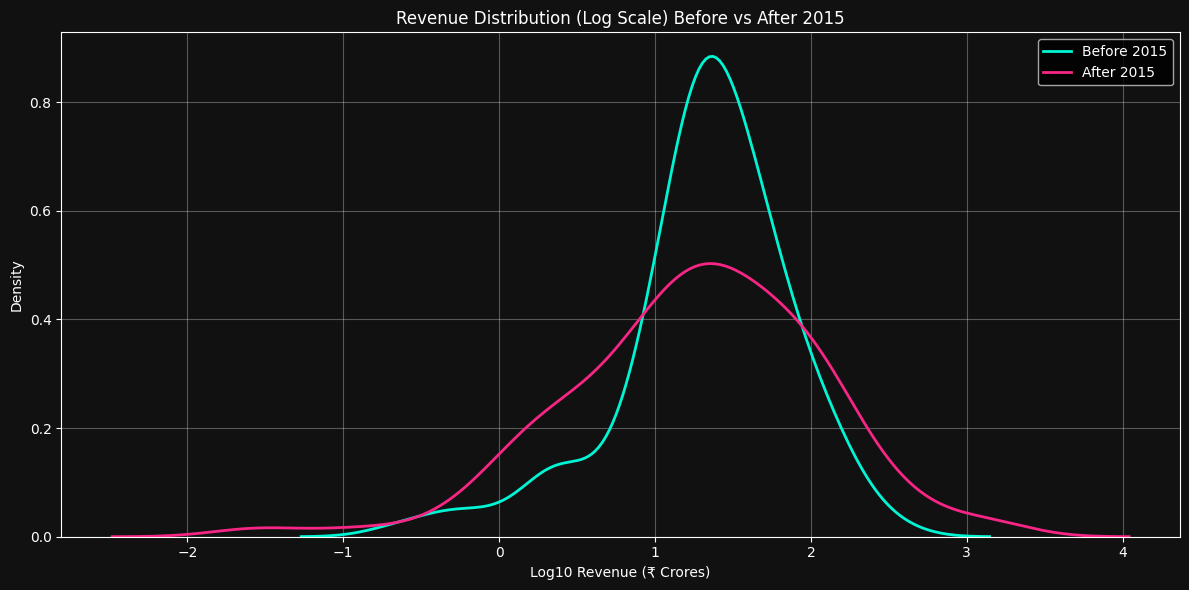

In [36]:


bg = "#111111"
plt.figure(figsize=(12,6), facecolor=bg)
ax = plt.gca()
ax.set_facecolor(bg)

# Applying log10 transform (avoid issues with 0)
df["Revenue_log"] = np.log10(df["Box Office Revenue"].replace(0, np.nan))


before_2015 = df[df["Released Year"] < 2015]
after_2015  = df[df["Released Year"] >= 2015]

sns.kdeplot(
    data=before_2015,
    x="Revenue_log",
    linewidth=2,
    label="Before 2015",
    color= "#00f5d4"
)

sns.kdeplot(
    data=after_2015,
    x="Revenue_log",
    linewidth=2,
    label="After 2015",
    color="#f72585"
)

plt.title("Revenue Distribution (Log Scale) Before vs After 2015")
plt.xlabel("Log10 Revenue (₹ Crores)")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### HEAT MAP

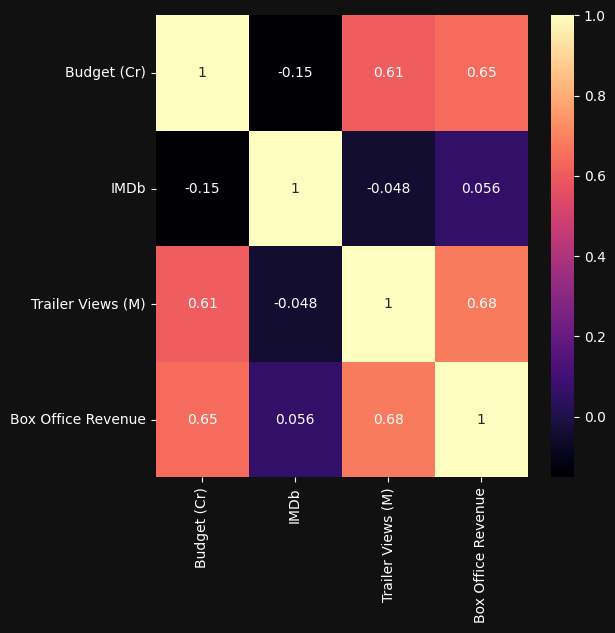

In [37]:
bg = "#111111"   
plt.figure(figsize=(6,6), facecolor=bg)
ax = plt.gca()
ax.set_facecolor(bg)
sns.heatmap(
    df[["Budget (Cr)", "IMDb", "Trailer Views (M)", "Box Office Revenue"]].corr(),
    annot=True,
    cmap="magma"
)
plt.show()


#### Bar Plot Average IMDb Rating by Genre

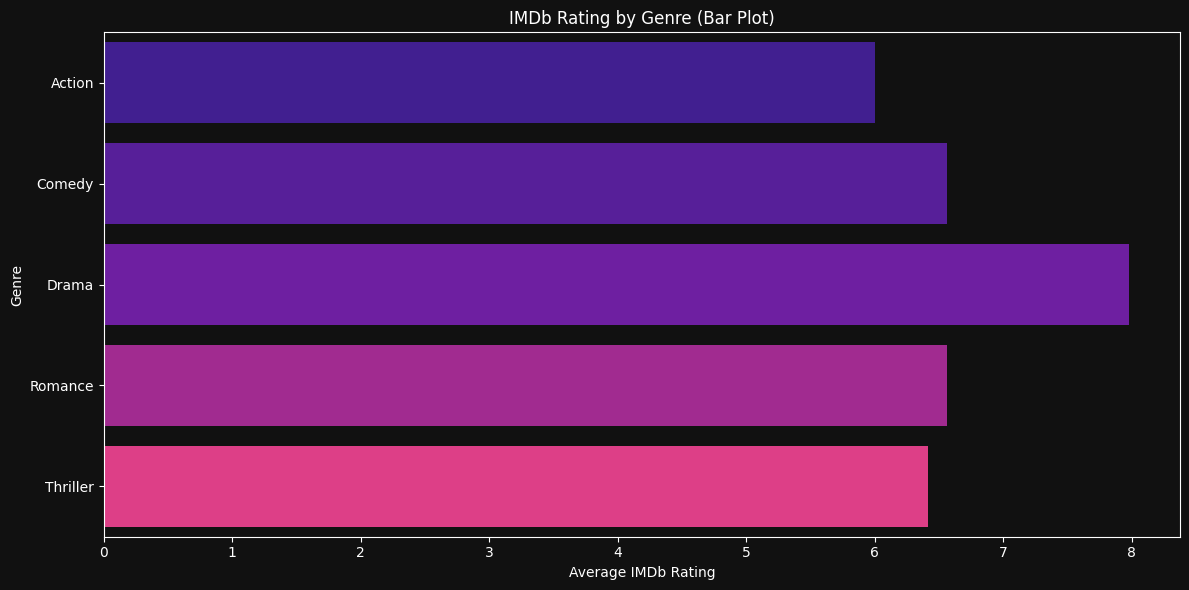

In [38]:
genre_imdb = df.groupby("Genre")["IMDb"].mean()

bg = "#111111"   
plt.figure(figsize=(12,6), facecolor=bg)
ax = plt.gca()
ax.set_facecolor(bg)

sns.barplot(x=genre_imdb.values,
            y=genre_imdb.index, 
            palette=colors * (len(genre_imdb) // len(colors) + 1))

plt.xlabel("Average IMDb Rating")
plt.ylabel("Genre")
plt.title("IMDb Rating by Genre (Bar Plot)")
plt.tight_layout()
plt.show()


#### PAIR PLOT

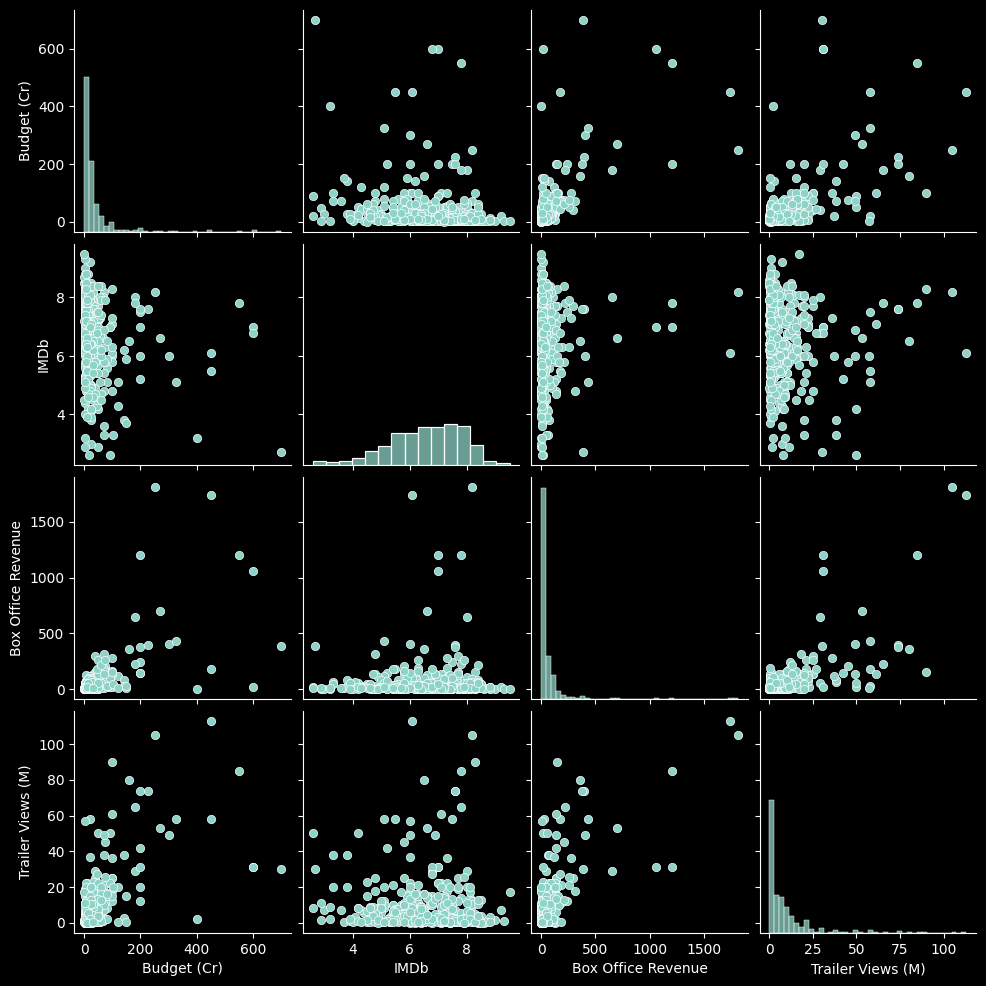

In [39]:

pair_cols = ["Budget (Cr)", "IMDb", "Box Office Revenue", "Trailer Views (M)"]
pp_df = df[pair_cols].dropna()
sns.pairplot(pp_df) 
plt.show()

#### SCATTERPLOT Trailer Views vs IMDb Rating

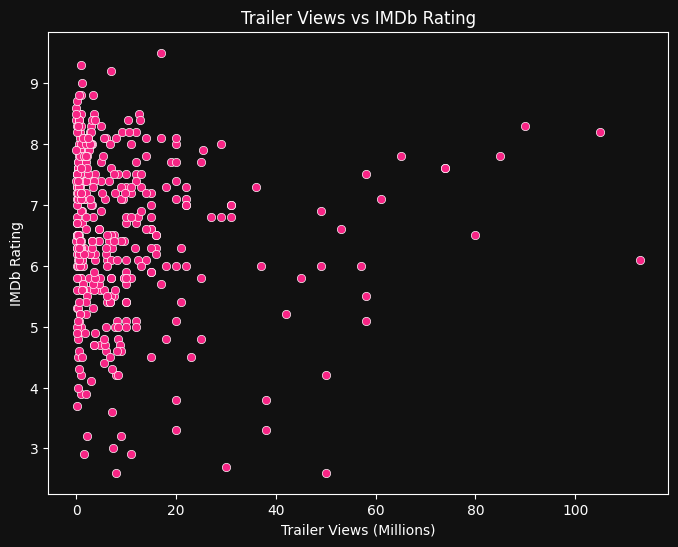

In [40]:
bg = "#111111"   
plt.figure(figsize=(8,6), facecolor=bg)
ax = plt.gca()
ax.set_facecolor(bg)
sns.scatterplot(x=df["Trailer Views (M)"],y= df["IMDb"],color="#f72585")
plt.xlabel("Trailer Views (Millions)")
plt.ylabel("IMDb Rating")
plt.title("Trailer Views vs IMDb Rating")
plt.show()



#### Line plot Budget vs Revenue

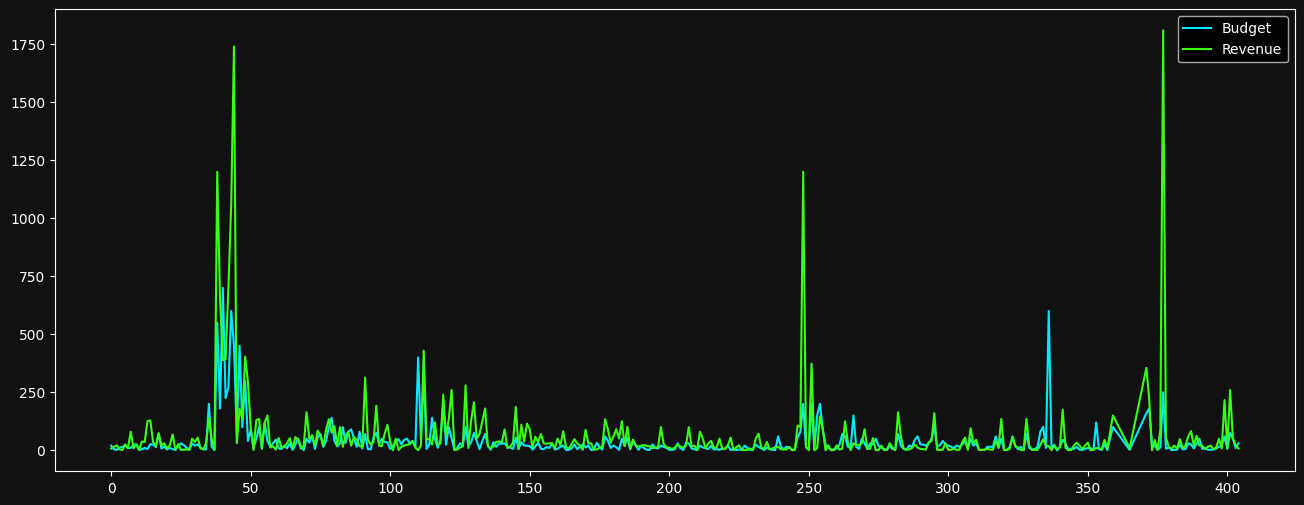

In [41]:
bg = "#111111"   
plt.figure(figsize=(16,6), facecolor=bg)
ax = plt.gca()
ax.set_facecolor(bg)
plt.plot(df["Budget (Cr)"], label="Budget", color="#00eaff")
plt.plot(df["Box Office Revenue"], label="Revenue",color="#39ff14")
plt.legend()
plt.show()


#### Line PLot Revenue Per Year

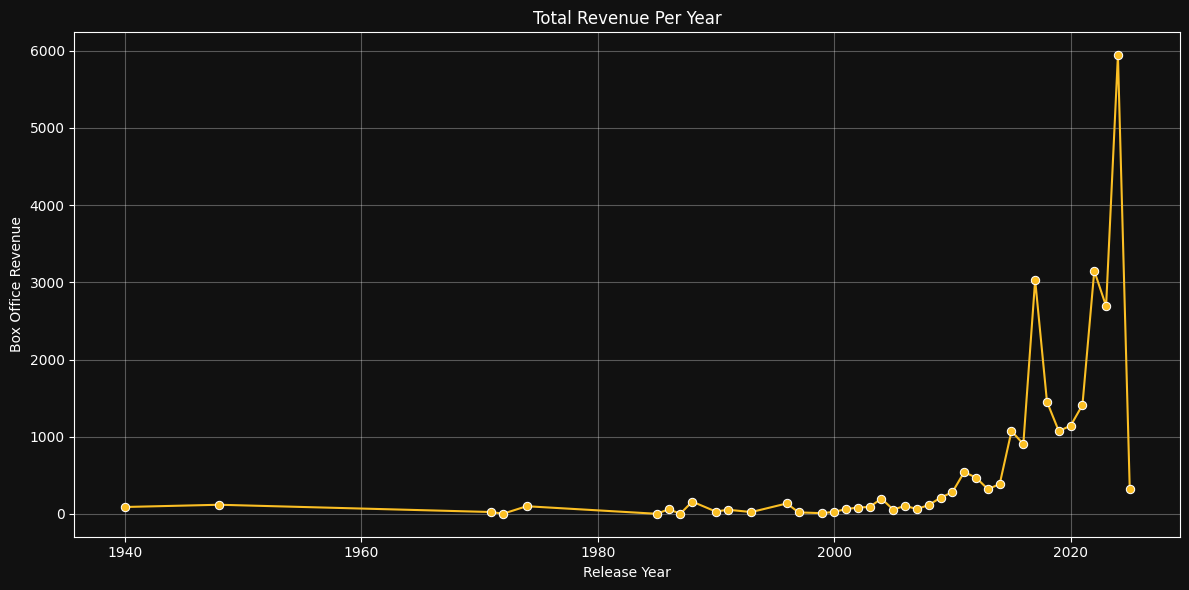

In [42]:
revenue_per_year = df.groupby("Released Year")["Box Office Revenue"].sum().reset_index()

bg = "#111111"   
plt.figure(figsize=(12,6), facecolor=bg)
ax = plt.gca()
ax.set_facecolor(bg)
sns.lineplot(
    data=revenue_per_year,
    x="Released Year",
    y="Box Office Revenue",
    marker="o",
    color = "#fbbf24"

)

plt.title("Total Revenue Per Year")
plt.xlabel("Release Year")
plt.ylabel("Box Office Revenue")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Count PLot (Movies Count by Genre)

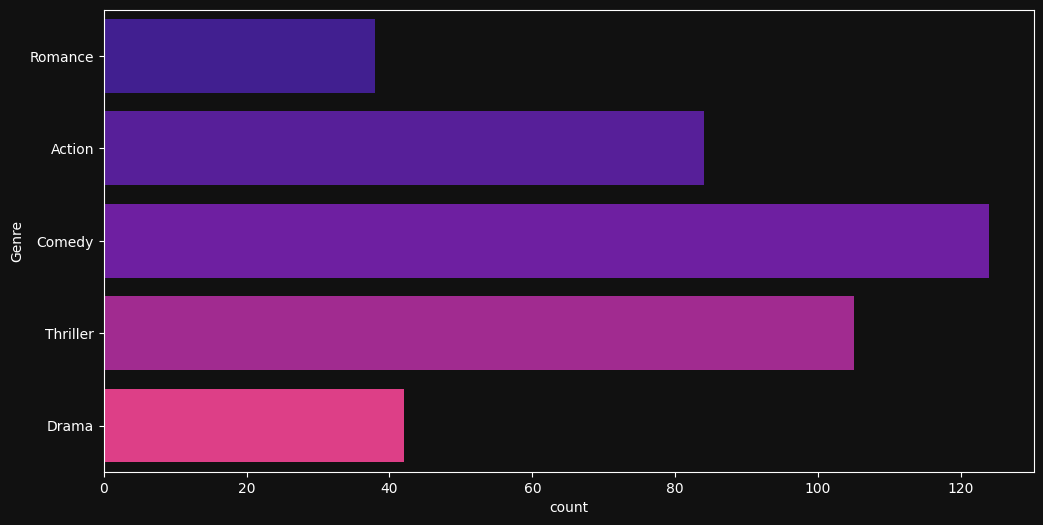

In [43]:
bg = "#111111"
plt.figure(figsize=(12,6), facecolor=bg)
ax = plt.gca()
ax.set_facecolor(bg)
sns.countplot(df["Genre"],palette=colors * (len(genre_imdb) // len(colors) + 1))
plt.show()

In [94]:
df[(df["Budget (Cr)"]<10) & (df["Box Office Revenue"]>20)]

,S.no,Movie Title,Genre,Budget (Cr),Director Success Rate,Lead Actor Success Rate,IMDb,Trailer Views (M),Box Office Revenue,Released Year
2,2,Ammammagarillu,Romance,1.50,0.0,23.00,5.3,0.221,21.50,2018.0
11,11,Dear Comrade,Romance,5.00,100.0,46.15,7.3,18.000,37.33,2019.0
13,13,DJ Tillu,Romance,5.00,25.0,85.71,7.2,15.000,125.00,2022.0
22,22,Majili,Romance,5.00,60.0,52.00,7.3,10.000,68.05,2019.0
34,34,Prince,Romance,4.00,75.0,68.75,4.4,5.500,30.00,2021.0
60,101,Indra,Action,8.00,75.0,60.00,7.5,0.189,53.00,2002.0
63,104,Simhadri,Action,8.50,100.0,51.72,7.3,0.680,30.00,2003.0
73,114,Bhadra,Action,6.00,60.0,52.50,6.8,0.041,21.00,2005.0
92,133,Tuck Jagadish,Action,5.00,66.0,65.00,5.6,3.500,45.00,2021.0
93,134,Zombie reddy,Action,4.00,66.0,60.00,6.6,4.500,25.00,2021.0


In [96]:
df["Profit %"]=(df["Profit"]/df["Budget  (Cr)"])*100

KeyError: 'Profit'

In [ ]:
df["Profi"]